In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

student_name = "Jenny Guevarra"
student_id = "20254172"

id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

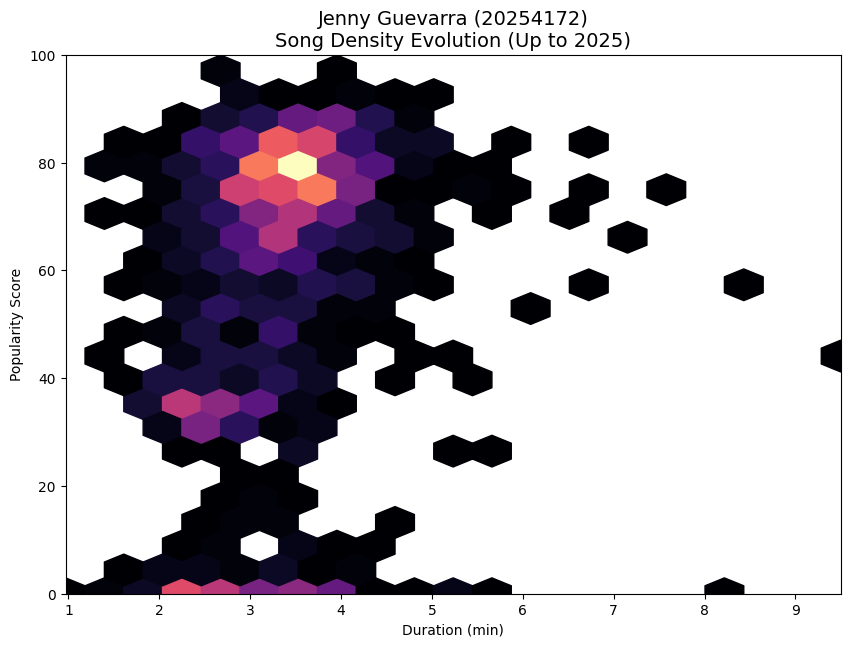

⬛ Animation saved successfully as: c:\Users\MSI1\OneDrive\Documents\Desktop\Lab7\Lab7_Additional_Exercises\exercise3_density_map.gif


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os

dataset_path = "spotify_top_1000_tracks[1].csv"
df = pd.read_csv(dataset_path)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df_clean = df.dropna(subset=['year', 'duration_min', 'popularity'])
years = sorted(df_clean['year'].unique())

fig, ax = plt.subplots(figsize=(10, 7))

def update(frame):
    ax.clear()
    current_year = years[frame]
    
    data_to_plot = df_clean[df_clean['year'] <= current_year]
    
    hb = ax.hexbin(
        data_to_plot['duration_min'], 
        data_to_plot['popularity'], 
        gridsize=20, 
        cmap='magma', 
        mincnt=1
    )
    
    ax.set_title(f"{student_name} ({student_id})\nSong Density Evolution (Up to {int(current_year)})", fontsize=14)
    ax.set_xlabel('Duration (min)')
    ax.set_ylabel('Popularity Score')
    
    ax.set_xlim(df_clean['duration_min'].min(), df_clean['duration_min'].max())
    ax.set_ylim(0, 100)
    return hb,

ani = FuncAnimation(fig, update, frames=len(years), interval=200, repeat=False)

gif_output = "exercise3_density_map.gif"
ani.save(gif_output, writer=PillowWriter(fps=5))

plt.show()
print(f"⬛ Animation saved successfully as: {os.path.abspath(gif_output)}")